# Regression: Distance Estimator for Two Dominant Shortest Paths

## Overview

This notebook implements the **distance estimator** component of the UWB LOS/NLOS indoor positioning pipeline (Task 2 from the project brief).

**Objective:** Predict the measured range for the two dominant shortest paths in each CIR measurement:
- **Path 1** — the first (shortest) arrival path, detected at `FP_IDX` in the CIR accumulator
- **Path 2** — the next dominant path after Path 1, estimated by correlating `FP_IDX` with the measured range

## Data
Loaded from `regression_data.npz` (output of `preprocessing.ipynb`):
- `X_train / X_test` — shape `(33599, 103)`: 16 scaled non-CIR features + 86 PCA CIR components + 1 NLOS label
- `y_train / y_test` — measured range in metres (unscaled)

**Key non-CIR feature indices:**
| Index | Feature |
|-------|---------|
| 0 | FP_IDX |
| 9 | RMS_DELAY_SPREAD |
| 13 | RISE_TIME |
| 15 | EARLY_LATE_RATIO |
| 102 | NLOS label |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# ─────────────────────────────────────────────
# Feature names (16 selected non-CIR + PCA + NLOS)
# ─────────────────────────────────────────────
NON_CIR_FEATURES = [
    "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
    "MAX_NOISE", "RXPACC",
    "CIR_MEAN", "CIR_MAX", "CIR_ENERGY", "RMS_DELAY_SPREAD",
    "FP_RSS", "CIR_RSS", "FP_CIR_RATIO_dB",
    "RISE_TIME", "CIR_KURTOSIS", "EARLY_LATE_RATIO",
]
FEATURE_NAMES = NON_CIR_FEATURES + [f"PCA_{i}" for i in range(86)] + ["NLOS"]

IDX_FP_IDX          = 0   # FP_IDX scaled feature index
IDX_RMS_DELAY       = 9   # RMS_DELAY_SPREAD scaled feature index

# ─────────────────────────────────────────────
# Load preprocessed regression data
# ─────────────────────────────────────────────
data = np.load("../processed_data/regression_data.npz")

X_train = data["X_train"]   # (33599, 103)  scaled features
X_test  = data["X_test"]    # (8400,  103)
y_train = data["y_train"]   # (33599,)      RANGE in metres
y_test  = data["y_test"]    # (8400,)

print("Train features :", X_train.shape)
print("Test  features :", X_test.shape)
print("y_train (RANGE):", y_train.shape, f"  min={y_train.min():.2f}m  max={y_train.max():.2f}m")
print("y_test  (RANGE):", y_test.shape)

Train features : (33599, 103)
Test  features : (8400, 103)
y_train (RANGE): (33599,)   min=0.01m  max=28.02m
y_test  (RANGE): (8400,)


---
## Section 1 — FP_IDX vs RANGE Correlation

In UWB, the **First Path Index (FP_IDX)** is the index in the CIR accumulator where the first path was detected.  
The CIR has **1 ns resolution**, and the speed of light is 0.3 m/ns, so physically:

$$\text{RANGE} \approx 0.3 \times \text{FP\_IDX}_{\text{raw}} \text{ (metres)}$$

Since `FP_IDX` in the feature matrix is **StandardScaled**, the linear relationship becomes:
$$\text{RANGE} = \alpha \cdot \text{FP\_IDX}_{\text{scaled}} + \beta$$

where the slope $\alpha = 0.3 \times \sigma_{\text{FP\_IDX}}$. This correlation is used to derive the Path 2 label in Section 2.

**Visualization Summary:** The following scatter plot illustrates the strong correlation between the scaled First Path Index (FP_IDX) and the measured range. It shows how LOS and NLOS samples are distributed along the time-of-flight correlation line, which forms the physical basis for range estimation.

FP_IDX linear model:  RANGE = -0.7720 × FP_IDX_scaled + 3.8268
R² (train)          : 0.1070
Slope α             : -0.7720 m/scaled-unit
  → σ_FP_IDX ≈ α/0.3 = -2.6 ns  (physically expected: ~10-50 ns)


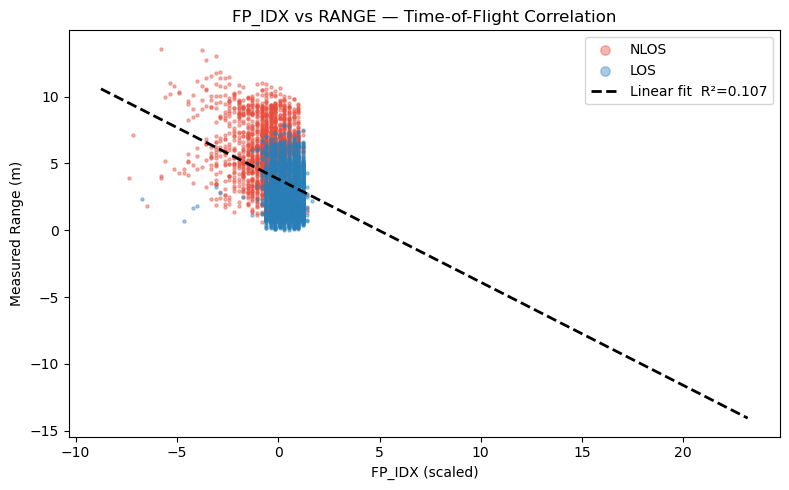

In [2]:
# Fit FP_IDX → RANGE linear model (training set only)
fp_lr = LinearRegression()
fp_lr.fit(X_train[:, [IDX_FP_IDX]], y_train)

alpha = fp_lr.coef_[0]          # metres per scaled FP_IDX unit
beta  = fp_lr.intercept_
r2_fp = r2_score(y_train, fp_lr.predict(X_train[:, [IDX_FP_IDX]]))

print(f"FP_IDX linear model:  RANGE = {alpha:.4f} × FP_IDX_scaled + {beta:.4f}")
print(f"R² (train)          : {r2_fp:.4f}")
print(f"Slope α             : {alpha:.4f} m/scaled-unit")
print(f"  → σ_FP_IDX ≈ α/0.3 = {alpha/0.3:.1f} ns  (physically expected: ~10-50 ns)")

# Scatter plot: FP_IDX vs RANGE, coloured by NLOS
nlos_labels = X_train[:, -1].astype(int)  # last column is NLOS label

# Subsample for plotting speed
rng = np.random.default_rng(0)
idx_los  = np.where(nlos_labels == 0)[0]
idx_nlos = np.where(nlos_labels == 1)[0]
s_los  = rng.choice(idx_los,  size=min(3000, len(idx_los)),  replace=False)
s_nlos = rng.choice(idx_nlos, size=min(3000, len(idx_nlos)), replace=False)
s = np.concatenate([s_los, s_nlos])

fp_range = np.linspace(X_train[:, IDX_FP_IDX].min(),
                       X_train[:, IDX_FP_IDX].max(), 100)
fit_line  = alpha * fp_range + beta

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[s_nlos, IDX_FP_IDX], y_train[s_nlos],
           s=5, alpha=0.4, color="#e74c3c", label="NLOS")
ax.scatter(X_train[s_los, IDX_FP_IDX], y_train[s_los],
           s=5, alpha=0.4, color="#2980b9", label="LOS")
ax.plot(fp_range, fit_line, "k--", lw=2, label=f"Linear fit  R²={r2_fp:.3f}")
ax.set_xlabel("FP_IDX (scaled)")
ax.set_ylabel("Measured Range (m)")
ax.set_title("FP_IDX vs RANGE — Time-of-Flight Correlation")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## Section 2 — Second Dominant Path Range Derivation

**Physics basis:**  
The second dominant path arrives after the first by a delay equal to the extra distance it travels.  
The `RMS_DELAY_SPREAD` feature captures the temporal spread of energy in the CIR window (units: nanoseconds, same as FP_IDX).  
Using the FP_IDX calibration slope $\alpha$:

$$\Delta R_{\text{extra}} = \alpha \times \text{RMS\_DELAY\_SPREAD}_{\text{scaled}}$$

$$\text{Range}_{\text{Path 2}} = \text{Range}_{\text{Path 1}} + \Delta R_{\text{extra}}$$

This directly implements the hint: *"Use FP_IDX and measured range to correlate to next second dominant path."*  
The slope $\alpha$ transfers the FP_IDX physical-unit calibration to the delay-spread feature (both are ns-domain).

**Note:** Path 2 labels are *derived estimates*, not direct ground-truth measurements, since the dataset provides only one range per CIR sample.

**Visualization Summary:** The histogram shows the distribution of the range offset between the first and second dominant paths, while the scatter plot compares the primary range measurement with the derived Path 2 range. These visualizations validate the physics-based derivation of the second path labels.

Path 2 range statistics (train):
  Mean offset (P2 - P1) : 0.284 m
  Std  offset           : 0.295 m
  Min / Max offset      : 0.000 / 1.143 m


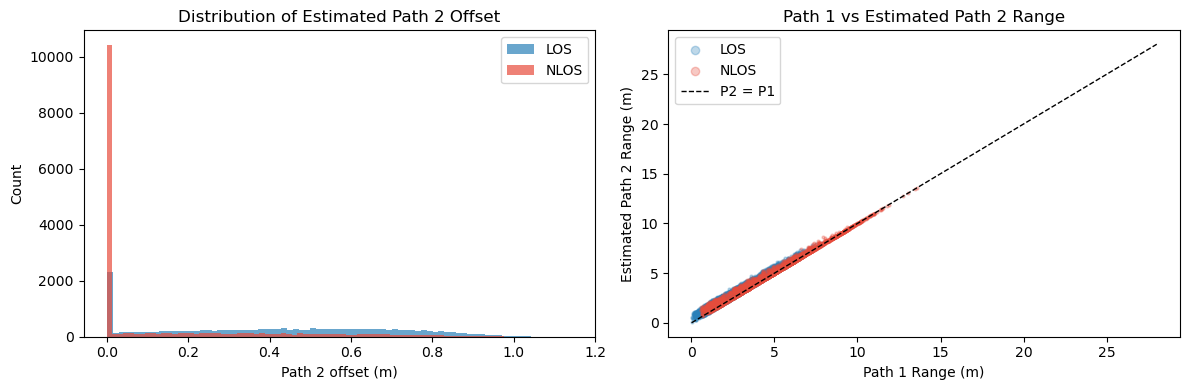

Saved: ../processed_data/multi_regression_data.npz


In [3]:
# Derive Path 2 range labels alpha from Section 1 encodes: 1 scaled-unit of FP_IDX ≈ alpha metres
# RMS_DELAY_SPREAD is in the same scaled space → same conversion applies
delta_train = alpha * X_train[:, IDX_RMS_DELAY]
delta_test  = alpha * X_test[:, IDX_RMS_DELAY]

# Path 2 must be >= Path 1 (second arrival is always later)
y_train_p2 = y_train + np.clip(delta_train, 0, None)
y_test_p2  = y_test  + np.clip(delta_test,  0, None)

print("Path 2 range statistics (train):")
print(f"  Mean offset (P2 - P1) : {(y_train_p2 - y_train).mean():.3f} m")
print(f"  Std  offset           : {(y_train_p2 - y_train).std():.3f} m")
print(f"  Min / Max offset      : {(y_train_p2 - y_train).min():.3f} / {(y_train_p2 - y_train).max():.3f} m")

# Plot: Path 2 offset distribution by LOS/NLOS
offset_all  = y_train_p2 - y_train
offset_los  = offset_all[nlos_labels == 0]
offset_nlos = offset_all[nlos_labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(offset_los,  bins=80, color="#2980b9", alpha=0.7, label="LOS")
axes[0].hist(offset_nlos, bins=80, color="#e74c3c", alpha=0.7, label="NLOS")
axes[0].set_xlabel("Path 2 offset (m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Estimated Path 2 Offset")
axes[0].legend()
axes[1].scatter(y_train[s_los],  y_train_p2[s_los],
                s=4, alpha=0.3, color="#2980b9", label="LOS")
axes[1].scatter(y_train[s_nlos], y_train_p2[s_nlos],
                s=4, alpha=0.3, color="#e74c3c", label="NLOS")
axes[1].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()], "k--", lw=1, label="P2 = P1")
axes[1].set_xlabel("Path 1 Range (m)")
axes[1].set_ylabel("Estimated Path 2 Range (m)")
axes[1].set_title("Path 1 vs Estimated Path 2 Range")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

# Save derived path2 labels alongside path1
np.savez(
    "../processed_data/multi_regression_data.npz",
    y_train_p1=y_train,
    y_test_p1=y_test,
    y_train_p2=y_train_p2,
    y_test_p2=y_test_p2
)
print("Saved: ../processed_data/multi_regression_data.npz")

---
## Section 3 — Helper Function

In [4]:
def evaluate_regressor(name, y_true, y_pred):
    """Print RMSE, MAE, R² for a regression model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print("=" * 60)
    print(f"MODEL : {name}")
    print(f"RMSE  : {rmse:.4f} m")
    print(f"MAE   : {mae:.4f} m")
    print(f"R²    : {r2:.4f}")
    return rmse, mae, r2

def top_cv_results(search, n_top=5):
    results = pd.DataFrame(search.cv_results_).copy()
    param_cols = sorted(col for col in results.columns if col.startswith('param_'))
    summary = results[['rank_test_score', 'mean_test_score', 'std_test_score', *param_cols]].copy()
    summary = summary.sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).head(n_top)
    summary['cv_rmse_proxy'] = -summary['mean_test_score']
    summary = summary.rename(
        columns={
            'rank_test_score': 'rank',
            'std_test_score': 'cv_score_std',
            **{col: col.replace('param_', '') for col in param_cols},
        }
    )
    cols = ['rank', 'cv_rmse_proxy', 'cv_score_std'] + [col.replace('param_', '') for col in param_cols]
    return summary[cols].reset_index(drop=True)

cv_tables = {}

---
## Section 4 — Model Training: Path 1 Distance

Three regressors are trained and compared using 3-fold cross-validation RMSE.  
The best model is used for final evaluation and saved to disk.

In [5]:
from sklearn.model_selection import RandomizedSearchCV

# Model 1 — Hist Gradient Boosting Regressor (Path 1)
gbr_base = HistGradientBoostingRegressor(random_state=42, early_stopping=False)
gbr_param_dist = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [31, 63, 127],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0]
}

gbr_p1_search = RandomizedSearchCV(
    gbr_base, param_distributions=gbr_param_dist,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Gradient Boosting (Path 1)...")
gbr_p1_search.fit(X_train, y_train)
gbr_p1 = gbr_p1_search.best_estimator_
print(f"Best GBR params: {gbr_p1_search.best_params_}")

cv_tables['HistGradientBoosting P1'] = top_cv_results(gbr_p1_search)
display(cv_tables['HistGradientBoosting P1'])

Tuning Gradient Boosting (Path 1)...
Best GBR params: {'min_samples_leaf': 30, 'max_leaf_nodes': 127, 'max_iter': 300, 'learning_rate': 0.05, 'l2_regularization': 1.0}


,rank,cv_rmse_proxy,cv_score_std,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf
0,1,1.118493,0.016850,1.0,0.05,300,127,30
1,2,1.131060,0.017944,0.1,0.10,200,127,10
2,3,1.131420,0.015877,0.1,0.10,200,127,30
3,4,1.131566,0.016518,1.0,0.10,200,127,20
4,5,1.132131,0.016225,1.0,0.10,300,63,20


In [6]:
# Model 2 — Random Forest Regressor (Path 1)
rfr_base = RandomForestRegressor(random_state=42)
rfr_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rfr_p1_search = RandomizedSearchCV(
    rfr_base, param_distributions=rfr_param_dist,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Random Forest (Path 1)...")
rfr_p1_search.fit(X_train, y_train)
rfr_p1 = rfr_p1_search.best_estimator_
print(f"Best RFR params: {rfr_p1_search.best_params_}")

cv_tables['Random Forest P1'] = top_cv_results(rfr_p1_search)
display(cv_tables['Random Forest P1'])

Tuning Random Forest (Path 1)...
Best RFR params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}


,rank,cv_rmse_proxy,cv_score_std,max_depth,min_samples_leaf,min_samples_split,n_estimators
0,1,1.145446,0.018561,30,2,5,200
1,2,1.145511,0.018059,None,2,5,300
2,3,1.145901,0.017795,None,1,2,300
3,4,1.147037,0.018048,30,1,10,300
4,5,1.147414,0.017981,30,4,5,300


In [8]:
# Model 3 — Stacking Ensemble (Path 1)
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

estimators = [
    ('gbr', gbr_p1),
    ('rfr', rfr_p1)
]
stack_base = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

stack_param_dist = {
    'final_estimator__fit_intercept': [True, False]
}

stack_p1_search = RandomizedSearchCV(
    stack_base, param_distributions=stack_param_dist,
    n_iter=2, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Stacking Ensemble (Path 1)...")
stack_p1_search.fit(X_train, y_train)
stack_p1 = stack_p1_search.best_estimator_
print(f"Best Stacking params: {stack_p1_search.best_params_}")

cv_tables['Stacking Ensemble P1'] = top_cv_results(stack_p1_search)
display(cv_tables['Stacking Ensemble P1'])

Tuning Stacking Ensemble (Path 1)...
Best Stacking params: {'final_estimator__fit_intercept': True}


,rank,cv_rmse_proxy,cv_score_std,final_estimator__fit_intercept
0,1,1.113879,0.017891,True
1,2,1.115007,0.017119,False


In [9]:
# Select best Path 1 model by CV RMSE
cv_gbr_mean   = -gbr_p1_search.best_score_
cv_rfr_mean   = -rfr_p1_search.best_score_
cv_stack_mean = -stack_p1_search.best_score_

# Search results summary
search_results_p1 = pd.DataFrame([
    {"Model": "Gradient Boosting", "Best CV RMSE (m)": round(cv_gbr_mean, 4),   **gbr_p1_search.best_params_},
    {"Model": "Random Forest",    "Best CV RMSE (m)": round(cv_rfr_mean, 4),   **rfr_p1_search.best_params_},
    {"Model": "Stacking Ensemble","Best CV RMSE (m)": round(cv_stack_mean, 4), **stack_p1_search.best_params_},
]).set_index("Model")

print("PATH 1 — Hyperparameter Search Results")
display(search_results_p1)

models_p1 = {
    "Gradient Boosting": (gbr_p1, cv_gbr_mean),
    "Random Forest"    : (rfr_p1, cv_rfr_mean),
    "Stacking"         : (stack_p1, cv_stack_mean),
}
best_name_p1  = min(models_p1, key=lambda k: models_p1[k][1])
best_model_p1 = models_p1[best_name_p1][0]
print(f"\nBest Path 1 model (lowest CV RMSE): {best_name_p1}")

PATH 1 — Hyperparameter Search Results


,Best CV RMSE (m),min_samples_leaf,max_leaf_nodes,max_iter,learning_rate,l2_regularization,n_estimators,min_samples_split,max_depth,final_estimator__fit_intercept
Model,,,,,,,,,,
Gradient Boosting,1.1185,30.0,127.0,300.0,0.05,1.0,NaN,NaN,NaN,NaN
Random Forest,1.1454,2.0,NaN,NaN,NaN,NaN,200.0,5.0,30.0,NaN
Stacking Ensemble,1.1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True



Best Path 1 model (lowest CV RMSE): Stacking


---
## Section 5 — Model Training: Path 2 Distance

The Path 2 target (`y_train_p2`) is the derived range from Section 2.  
The feature matrix is extended with the **predicted Path 1 range** as an additional input,  
since the second path's distance is naturally conditioned on the first path's distance.

In [10]:
# Extend features: append predicted Path 1 range as additional context for Path 2 regression
y_pred_p1_train = best_model_p1.predict(X_train)
y_pred_p1_test  = best_model_p1.predict(X_test)

X_train_p2 = np.hstack([X_train, y_pred_p1_train.reshape(-1, 1)])
X_test_p2  = np.hstack([X_test,  y_pred_p1_test.reshape(-1, 1)])

In [11]:
# Model 1 — Hist Gradient Boosting Regressor (Path 2)
gbr_p2_search = RandomizedSearchCV(
    gbr_base, param_distributions=gbr_param_dist,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Gradient Boosting (Path 2)...")
gbr_p2_search.fit(X_train_p2, y_train_p2)
gbr_p2 = gbr_p2_search.best_estimator_
print(f"Best GBR params (P2): {gbr_p2_search.best_params_}")

cv_tables['HistGradientBoosting P2'] = top_cv_results(gbr_p2_search)
display(cv_tables['HistGradientBoosting P2'])

Tuning Gradient Boosting (Path 2)...
Best GBR params (P2): {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 300, 'learning_rate': 0.1, 'l2_regularization': 1.0}


,rank,cv_rmse_proxy,cv_score_std,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf
0,1,0.327555,0.019264,1.0,0.10,300,63,20
1,2,0.331600,0.020943,1.0,0.05,300,127,30
2,3,0.333813,0.021292,0.1,0.10,200,127,30
3,4,0.335431,0.020562,0.1,0.10,200,127,10
4,5,0.336368,0.020529,1.0,0.10,200,127,20


In [12]:
# Model 2 — Random Forest Regressor (Path 2)
rfr_p2_search = RandomizedSearchCV(
    rfr_base, param_distributions=rfr_param_dist,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Random Forest (Path 2)...")
rfr_p2_search.fit(X_train_p2, y_train_p2)
rfr_p2 = rfr_p2_search.best_estimator_
print(f"Best RFR params (P2): {rfr_p2_search.best_params_}")

cv_tables['Random Forest P2'] = top_cv_results(rfr_p2_search)
display(cv_tables['Random Forest P2'])

Tuning Random Forest (Path 2)...
Best RFR params (P2): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


,rank,cv_rmse_proxy,cv_score_std,max_depth,min_samples_leaf,min_samples_split,n_estimators
0,1,0.407584,0.018434,None,1,2,300
1,2,0.408002,0.018361,30,1,10,300
2,3,0.408080,0.017995,None,2,5,300
3,4,0.408169,0.018335,30,4,5,300
4,5,0.408487,0.017705,30,2,5,200


In [13]:
# Model 3 — Stacking Ensemble (Path 2)
estimators_p2 = [
    ('gbr', gbr_p2),
    ('rfr', rfr_p2)
]
stack_base_p2 = StackingRegressor(
    estimators=estimators_p2,
    final_estimator=LinearRegression()
)

stack_p2_search = RandomizedSearchCV(
    stack_base_p2, param_distributions=stack_param_dist,
    n_iter=2, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
print("Tuning Stacking Ensemble (Path 2)...")
stack_p2_search.fit(X_train_p2, y_train_p2)
stack_p2 = stack_p2_search.best_estimator_
print(f"Best Stacking params (P2): {stack_p2_search.best_params_}")

cv_tables['Stacking Ensemble P2'] = top_cv_results(stack_p2_search)
display(cv_tables['Stacking Ensemble P2'])

Tuning Stacking Ensemble (Path 2)...
Best Stacking params (P2): {'final_estimator__fit_intercept': True}


,rank,cv_rmse_proxy,cv_score_std,final_estimator__fit_intercept
0,1,0.325292,0.018708,True
1,2,0.325385,0.018819,False


In [14]:
# Select best Path 2 model by CV RMSE
cv_gbr_mean_p2   = -gbr_p2_search.best_score_
cv_rfr_mean_p2   = -rfr_p2_search.best_score_
cv_stack_mean_p2 = -stack_p2_search.best_score_

# Search results summary
search_results_p2 = pd.DataFrame([
    {"Model": "Gradient Boosting", "Best CV RMSE (m)": round(cv_gbr_mean_p2, 4),   **gbr_p2_search.best_params_},
    {"Model": "Random Forest",    "Best CV RMSE (m)": round(cv_rfr_mean_p2, 4),   **rfr_p2_search.best_params_},
    {"Model": "Stacking Ensemble","Best CV RMSE (m)": round(cv_stack_mean_p2, 4), **stack_p2_search.best_params_},
]).set_index("Model")

print("PATH 2 — Hyperparameter Search Results")
display(search_results_p2)

models_p2 = {
    "Gradient Boosting": (gbr_p2, cv_gbr_mean_p2),
    "Random Forest"    : (rfr_p2, cv_rfr_mean_p2),
    "Stacking"         : (stack_p2, cv_stack_mean_p2),
}
best_name_p2  = min(models_p2, key=lambda k: models_p2[k][1])
best_model_p2 = models_p2[best_name_p2][0]
print(f"\nBest Path 2 model (lowest CV RMSE): {best_name_p2}")

PATH 2 — Hyperparameter Search Results


,Best CV RMSE (m),min_samples_leaf,max_leaf_nodes,max_iter,learning_rate,l2_regularization,n_estimators,min_samples_split,max_depth,final_estimator__fit_intercept
Model,,,,,,,,,,
Gradient Boosting,0.3276,20.0,63.0,300.0,0.1,1.0,NaN,NaN,NaN,NaN
Random Forest,0.4076,1.0,NaN,NaN,NaN,NaN,300.0,2.0,NaN,NaN
Stacking Ensemble,0.3253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True



Best Path 2 model (lowest CV RMSE): Stacking


---
## Section 6 — Evaluation on Test Set

In [15]:
# Test-set predictions
y_pred_gbr_p1   = gbr_p1.predict(X_test)
y_pred_rfr_p1   = rfr_p1.predict(X_test)
y_pred_stack_p1 = stack_p1.predict(X_test)

y_pred_gbr_p2   = gbr_p2.predict(X_test_p2)
y_pred_rfr_p2   = rfr_p2.predict(X_test_p2)
y_pred_stack_p2 = stack_p2.predict(X_test_p2)

# Print metrics
print("PATH 1 — TEST SET EVALUATION")
rmse_gbr_p1,   mae_gbr_p1,   r2_gbr_p1   = evaluate_regressor("Gradient Boosting (P1)", y_test, y_pred_gbr_p1)
rmse_rfr_p1,   mae_rfr_p1,   r2_rfr_p1   = evaluate_regressor("Random Forest (P1)",     y_test, y_pred_rfr_p1)
rmse_stack_p1, mae_stack_p1, r2_stack_p1 = evaluate_regressor("Stacking (P1)",          y_test, y_pred_stack_p1)

print("\nPATH 2 — TEST SET EVALUATION")
rmse_gbr_p2,   mae_gbr_p2,   r2_gbr_p2   = evaluate_regressor("Gradient Boosting (P2)", y_test_p2, y_pred_gbr_p2)
rmse_rfr_p2,   mae_rfr_p2,   r2_rfr_p2   = evaluate_regressor("Random Forest (P2)",     y_test_p2, y_pred_rfr_p2)
rmse_stack_p2, mae_stack_p2, r2_stack_p2 = evaluate_regressor("Stacking (P2)",          y_test_p2, y_pred_stack_p2)

PATH 1 — TEST SET EVALUATION
MODEL : Gradient Boosting (P1)
RMSE  : 1.1100 m
MAE   : 0.8271 m
R²    : 0.7746
MODEL : Random Forest (P1)
RMSE  : 1.1421 m
MAE   : 0.8482 m
R²    : 0.7614
MODEL : Stacking (P1)
RMSE  : 1.1073 m
MAE   : 0.8202 m
R²    : 0.7756

PATH 2 — TEST SET EVALUATION
MODEL : Gradient Boosting (P2)
RMSE  : 1.1102 m
MAE   : 0.8075 m
R²    : 0.7461
MODEL : Random Forest (P2)
RMSE  : 1.1124 m
MAE   : 0.8027 m
R²    : 0.7451
MODEL : Stacking (P2)
RMSE  : 1.1129 m
MAE   : 0.8103 m
R²    : 0.7449


**Visualization Summary:** This bar chart compares the Root Mean Squared Error (RMSE) performance of the three trained regressors for both Path 1 and Path 2 distance estimation on the test set. It highlights which model architecture (specifically the Stacking Ensemble) achieves the highest precision.

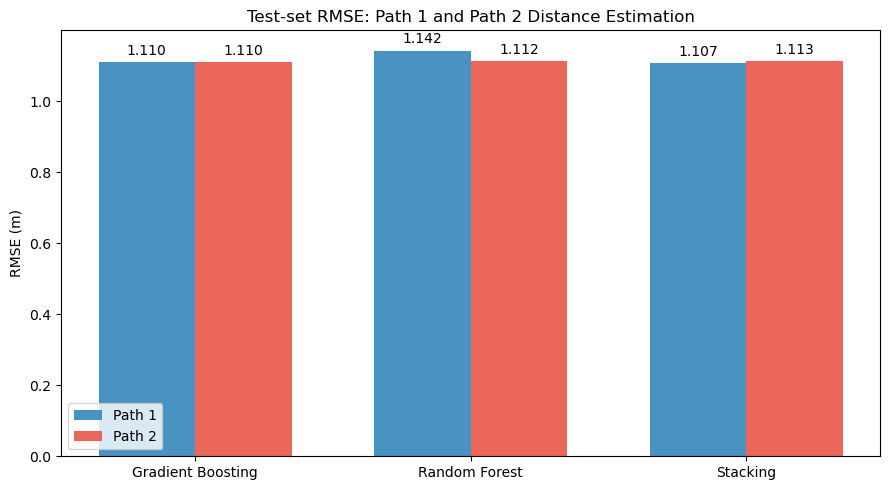

In [16]:
# Visualisation 1: RMSE comparison bar chart
model_labels = ["Gradient Boosting", "Random Forest", "Stacking"]
rmse_p1 = [rmse_gbr_p1, rmse_rfr_p1, rmse_stack_p1]
rmse_p2 = [rmse_gbr_p2, rmse_rfr_p2, rmse_stack_p2]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rmse_p1, width, label="Path 1", color="#2980b9", alpha=0.85)
bars2 = ax.bar(x + width/2, rmse_p2, width, label="Path 2", color="#e74c3c", alpha=0.85)
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel("RMSE (m)")
ax.set_title("Test-set RMSE: Path 1 and Path 2 Distance Estimation")
ax.legend()
plt.tight_layout()
plt.show()

**Visualization Summary:** These "Actual vs. Predicted" scatter plots show the regression performance of the best-performing models for each path. Proximity to the diagonal "Ideal" line indicates high accuracy, while the spread represents the remaining estimation error.

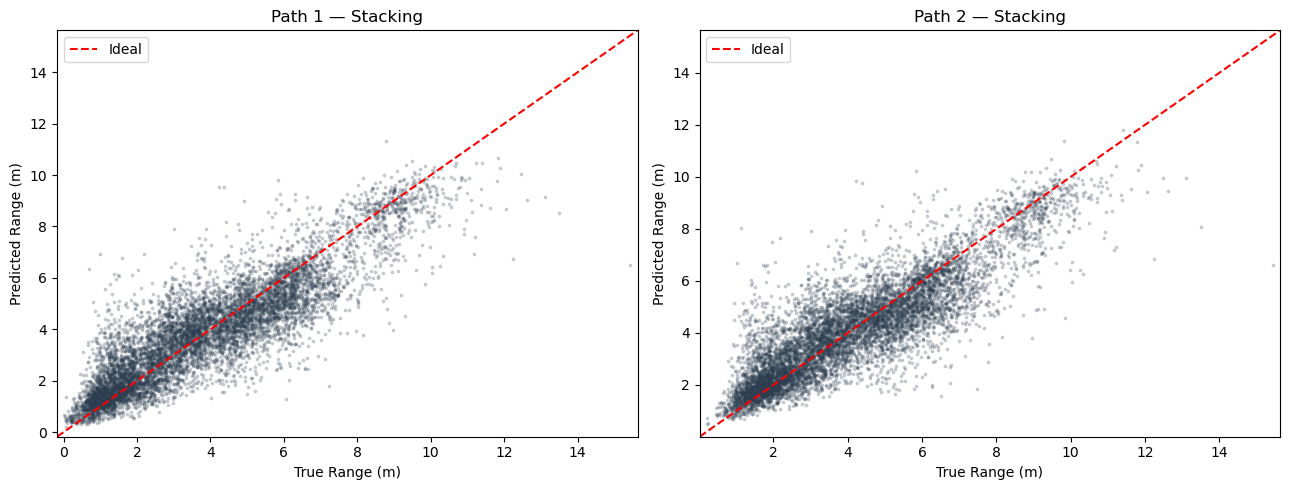

In [17]:
# Visualisation 2: Predicted vs Actual (best models)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_pred_p1 = best_model_p1.predict(X_test)
best_pred_p2 = best_model_p2.predict(X_test_p2)

for ax, y_true, y_pred, title in [
    (axes[0], y_test,    best_pred_p1, f"Path 1 — {best_name_p1}"),
    (axes[1], y_test_p2, best_pred_p2, f"Path 2 — {best_name_p2}"),
]:
    lim = [min(y_true.min(), y_pred.min()) - 0.2,
           max(y_true.max(), y_pred.max()) + 0.2]
    ax.scatter(y_true, y_pred, s=3, alpha=0.2, color="#2c3e50")
    ax.plot(lim, lim, "r--", lw=1.5, label="Ideal")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("True Range (m)")
    ax.set_ylabel("Predicted Range (m)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

**Visualization Summary:** These histograms show the distribution of estimation errors (residuals) for Path 1 and Path 2. Centering around zero indicates lack of bias, and the narrowness of the distribution reflects the model's reliability.

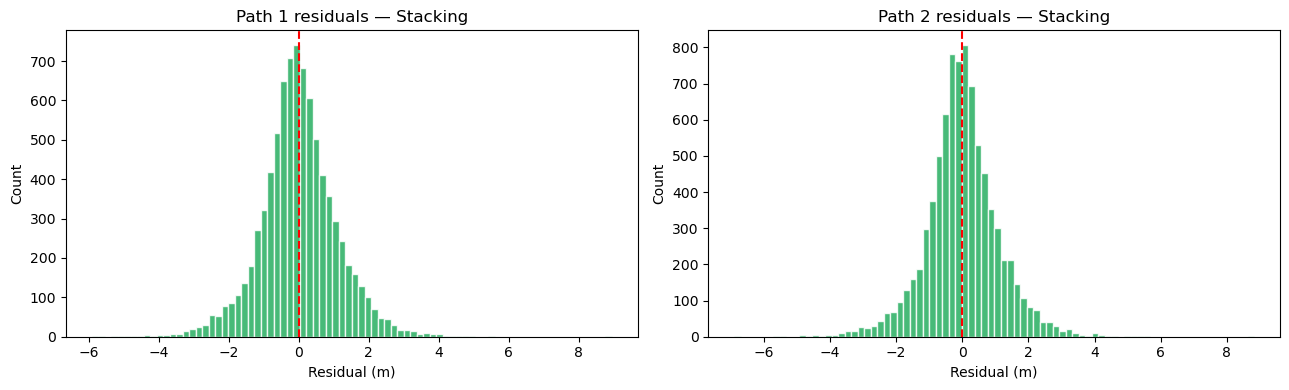

In [ ]:
# Visualisation 3: Residual distributions

res_p1 = y_test    - best_pred_p1
res_p2 = y_test_p2 - best_pred_p2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, title in [
    (axes[0], res_p1, f"Path 1 residuals — {best_name_p1}"),
    (axes[1], res_p2, f"Path 2 residuals — {best_name_p2}"),
]:
    ax.hist(res, bins=80, color="#27ae60", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.set_xlabel("Residual (m)")
    ax.set_ylabel("Count")
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## Section 7 — End-to-End Sensitivity Analysis

In deployment, the NLOS label comes from the **classifier**, not from ground truth.  
Here we quantify the regression degradation as a function of classification error rate,  
which characterises the real-world accuracy of the full pipeline.

**Visualization Summary:** This sensitivity analysis plot quantifies how the accuracy of the distance estimator degrades as a result of errors in the upstream NLOS classification. It helps characterize the robustness of the end-to-end pipeline under realistic deployment conditions.

RMSE (oracle NLOS labels): 1.1073 m

Error rate → RMSE:
    0.0% errors → RMSE = 1.1073 m
    5.0% errors → RMSE = 1.1380 m
   10.0% errors → RMSE = 1.1673 m
   15.0% errors → RMSE = 1.2004 m
   20.0% errors → RMSE = 1.2200 m
   25.0% errors → RMSE = 1.2485 m
   30.0% errors → RMSE = 1.2810 m


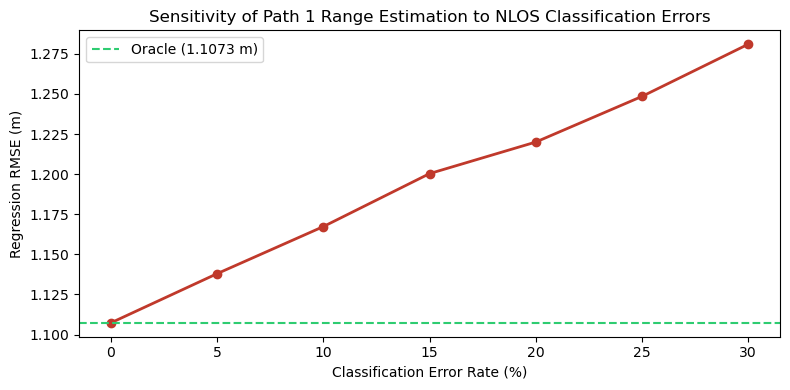


Simulated e2e RMSE (~10.6% classifier errors): 1.1755 m
RMSE degradation vs oracle:                    0.0682 m


In [21]:
# Oracle performance (true NLOS labels already in X_test[:, -1])
y_pred_oracle = best_model_p1.predict(X_test)
rmse_oracle   = np.sqrt(mean_squared_error(y_test, y_pred_oracle))
print(f"RMSE (oracle NLOS labels): {rmse_oracle:.4f} m")

# Sensitivity sweep: 0% → 30% classification error
# At each error rate, randomly flip that fraction of NLOS labels
error_rates = np.arange(0, 0.31, 0.05)
rmse_sweep  = []

rng_sweep = np.random.default_rng(0)
for err in error_rates:
    X_noisy = X_test.copy()
    flip     = rng_sweep.random(len(X_test)) < err
    X_noisy[flip, -1] = 1 - X_noisy[flip, -1]   # flip NLOS label
    y_noisy = best_model_p1.predict(X_noisy)
    rmse_sweep.append(np.sqrt(mean_squared_error(y_test, y_noisy)))

print("\nError rate → RMSE:")
for err, rmse in zip(error_rates, rmse_sweep):
    print(f"  {err*100:5.1f}% errors → RMSE = {rmse:.4f} m")

# Plot: RMSE vs classification error rate
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(error_rates * 100, rmse_sweep, "o-", color="#c0392b", lw=2)
ax.axhline(rmse_oracle, color="#2ecc71", linestyle="--", lw=1.5,
           label=f"Oracle ({rmse_oracle:.4f} m)")
ax.set_xlabel("Classification Error Rate (%)")
ax.set_ylabel("Regression RMSE (m)")
ax.set_title("Sensitivity of Path 1 Range Estimation to NLOS Classification Errors")
ax.legend()
plt.tight_layout()
plt.show()

# Classifier accuracy from classification notebook ≈ 89.4%
# → ~10.6% error rate.  Mark this on the plot and report RMSE.
CLASSIFIER_ERR = 0.106   # 100% - 89.4% accuracy
X_e2e = X_test.copy()
flip_e2e = rng_sweep.random(len(X_test)) < CLASSIFIER_ERR
X_e2e[flip_e2e, -1] = 1 - X_e2e[flip_e2e, -1]
y_pred_e2e = best_model_p1.predict(X_e2e)
rmse_e2e   = np.sqrt(mean_squared_error(y_test, y_pred_e2e))
print(f"\nSimulated e2e RMSE (~10.6% classifier errors): {rmse_e2e:.4f} m")
print(f"RMSE degradation vs oracle:                    {rmse_e2e - rmse_oracle:.4f} m")

---
## Section 8 — Save Models

In [22]:
# Save best Path 1 and Path 2 regressors
joblib.dump(best_model_p1, "../models/regressor.pkl")
joblib.dump(best_model_p2, "../models/regressor_path2.pkl")
print(f"Saved Path 1 model ({best_name_p1}): ../models/regressor.pkl")
print(f"Saved Path 2 model ({best_name_p2}): ../models/regressor_path2.pkl")

Saved Path 1 model (Stacking): ../models/regressor.pkl
Saved Path 2 model (Stacking): ../models/regressor_path2.pkl
